# Kelley resistance → AnnData

Bortezomib-resistant HCT116 clones ([`cpg0028`](https://broadinstitute.github.io/cellpainting-gallery/)), from the aggregated CSVs under `backend/`. Batches share only nine features, so one batch is used. Plate and well do not identify rows uniquely here either, so the default index is kept.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*.csv" \
  s3://cellpainting-gallery/cpg0028-kelley-resistance/broad/workspace/backend/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0028-kelley-resistance/profiles").expanduser()

## Scoping to one batch

Feature selection ran per batch, so batches carry different feature sets and intersecting across them throws most features away.
This takes the batch with the most plates.

In [2]:
batches = sorted({p.parents[1].name for p in PROFILES.glob("*/*/*.csv")})
BATCH = max(batches, key=lambda b: len(list((PROFILES / b).glob("*/*"))))
print(f"{len(batches)} batches, using {BATCH}")
files = sorted((PROFILES / BATCH).glob("*/*"))

28 batches, using 2020_09_08_Batch10


In [3]:
adata = cpio.read_profiles(files, path_columns={"batch": 2}, on_column_mismatch="intersect")
adata

/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 1920 × 221
    obs: 'Plate', 'Well', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_MedianRadius,cells,areashape,NaN,NaN,0
Cells_AreaShape_Orientation,cells,areashape,NaN,NaN,0
Cells_AreaShape_Zernike_1_1,cells,areashape,NaN,NaN,0
Cells_AreaShape_Zernike_2_0,cells,areashape,NaN,NaN,0
Cells_AreaShape_Zernike_2_2,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_Texture_InfoMeas1_ER_5_02,nuclei,texture,er,NaN,1
Nuclei_Texture_InfoMeas1_Mito_5_00,nuclei,texture,mito,NaN,1
Nuclei_Texture_InfoMeas1_RNA_5_03,nuclei,texture,rna,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Plate"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

1,920 wells x 221 features
non-finite: 0 | max|x|: 253666.6

Plate:
Plate
218852    240
218853    240
218854    240
218855    240
218856    240
218857    240


In [6]:
adata.write_h5ad(PROFILES.parent / "kelley.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "Site_Count"]))

,observed,baseline,ratio
covariate,,,
Plate,0.477,0.125,3.816


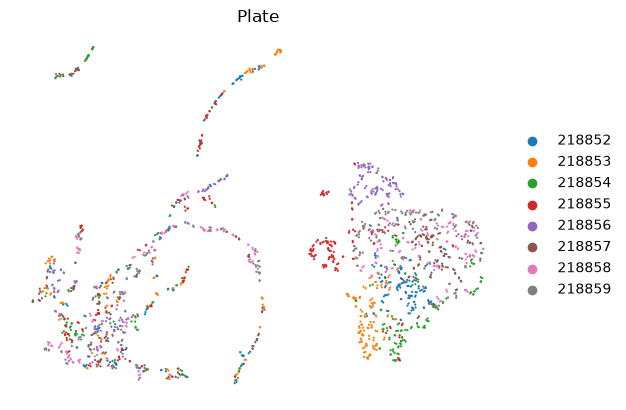

In [9]:
colours = present(["Plate", "Count_Cells"])[:3] or None
sc.pl.umap(adata, color=colours, ncols=3, frameon=False, size=10)